# Wine Neural Network Classification With SMOTE

This notebook trains a binary neural network on the wine quality dataset. Wines scored `8` or `9` are treated as `good_quality = 1`, while wines scored `7` or below are treated as `0`. SMOTE is applied to the training data only, and the test set is left unchanged.

In [23]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from imblearn.over_sampling import SMOTE
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE

try:
    import tensorflow as tf
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    import tensorflow as tf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## Load Data

The notebook reads the local wine dataset from the `Boosting Models` folder.

In [24]:
data_path = "/Users/eduardo/Desktop/Python_Coding/Applied-Data-Science-Classes/Machine Learning/Boosting Models/winequalityN.csv"

wine = pd.read_csv(data_path)
wine.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## Prepare Features

We create a binary target for good versus lower-quality wines, preprocess the data, select the Lasso-relevant variables, and keep a clean train-test split.

In [25]:
wine["good_quality"] = (wine["quality"] >= 8).astype(int)

X = wine.drop(columns=["quality", "good_quality"])
y = wine["good_quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in preprocessor.get_feature_names_out().tolist()
]

lasso_selector = LassoCV(cv=5, random_state=RANDOM_STATE)
lasso_selector.fit(X_train_processed, y_train)

selected_features = [feature for feature, coef in zip(feature_names, lasso_selector.coef_) if abs(coef) > 1e-8]
if not selected_features:
    selected_features = feature_names.copy()

selected_mask = np.array([feature in selected_features for feature in feature_names])
X_train_selected = X_train_processed[:, selected_mask]
X_test_selected = X_test_processed[:, selected_mask]

display(pd.DataFrame({"Selected Variables": selected_features}))
display(y.value_counts().sort_index().rename_axis("Class").reset_index(name="Count"))

,Selected Variables
0,fixed acidity
1,citric acid
2,residual sugar
3,free sulfur dioxide
4,total sulfur dioxide
5,density
6,pH
7,sulphates
8,alcohol


,Class,Count
0,0,6299
1,1,198


## SMOTE For Good Wines

We use SMOTE on the training data only so that the minority `good_quality = 1` class matches the majority `good_quality = 0` class.

In [26]:
train_distribution_before = y_train.value_counts().sort_index().rename_axis("Class").reset_index(name="Count")

target_count = int(y_train.value_counts().max())
smote = SMOTE(sampling_strategy={1: target_count}, random_state=RANDOM_STATE, k_neighbors=2)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

train_distribution_after = pd.Series(y_train_smote).value_counts().sort_index().rename_axis("Class").reset_index(name="Count")
balance_summary = train_distribution_before.merge(
    train_distribution_after,
    on="Class",
    how="outer",
    suffixes=(" Before SMOTE", " After SMOTE"),
).fillna(0)

display(balance_summary)

,Class,Count Before SMOTE,Count After SMOTE
0,0,4724,4724
1,1,148,4724


## Build The Neural Network

The target is binary, so the network ends with a sigmoid output layer.

In [27]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_smote.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=12,
    restore_best_weights=True,
)

history = model.fit(
    X_train_smote,
    y_train_smote,
    validation_split=0.2,
    epochs=120,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0,
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,261 (32.27 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,508 (21.52 KB)

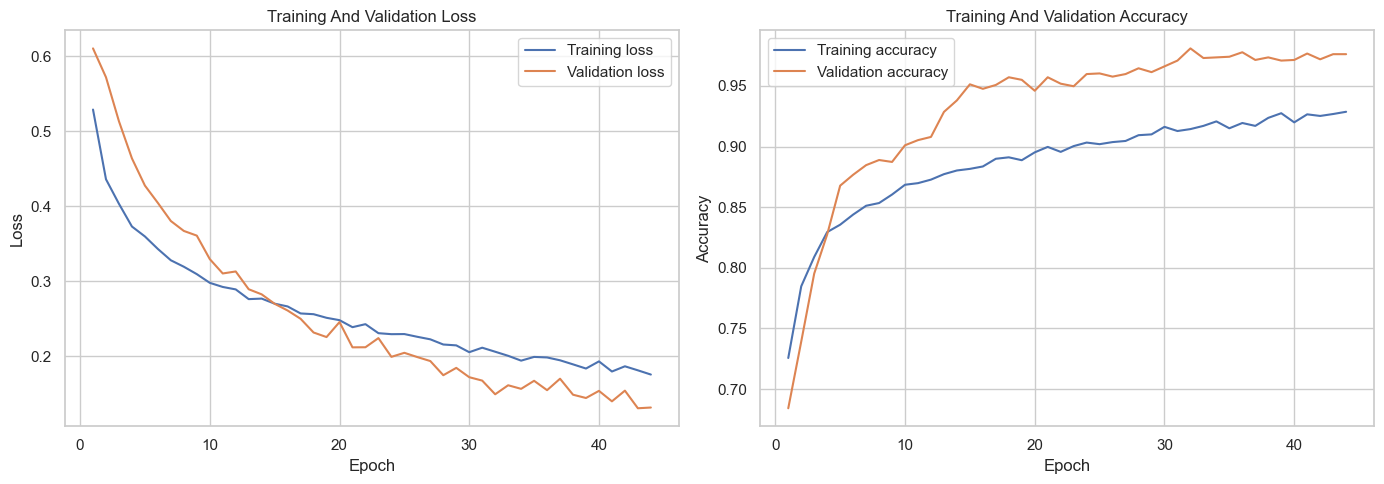

In [28]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df.index + 1, history_df["loss"], label="Training loss")
axes[0].plot(history_df.index + 1, history_df["val_loss"], label="Validation loss")
axes[0].set_title("Training And Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_df.index + 1, history_df["accuracy"], label="Training accuracy")
axes[1].plot(history_df.index + 1, history_df["val_accuracy"], label="Validation accuracy")
axes[1].set_title("Training And Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()

## Evaluate On The Original Test Set

The metrics below are computed on the untouched holdout set.

In [29]:
test_probabilities = model.predict(X_test_selected, verbose=0).ravel()
test_predictions = (test_probabilities >= 0.5).astype(int)

results = pd.DataFrame(
    {
        "Accuracy": [accuracy_score(y_test, test_predictions)],
        "Balanced Accuracy": [balanced_accuracy_score(y_test, test_predictions)],
        "Macro F1": [f1_score(y_test, test_predictions, average="macro")],
    }
)
display(results.round(3))

print(classification_report(y_test, test_predictions, target_names=["7 or less", "8 or 9"], zero_division=0))

,Accuracy,Balanced Accuracy,Macro F1
0,0.891,0.731,0.591


              precision    recall  f1-score   support

   7 or less       0.98      0.90      0.94      1575
      8 or 9       0.15      0.56      0.24        50

    accuracy                           0.89      1625
   macro avg       0.57      0.73      0.59      1625
weighted avg       0.96      0.89      0.92      1625



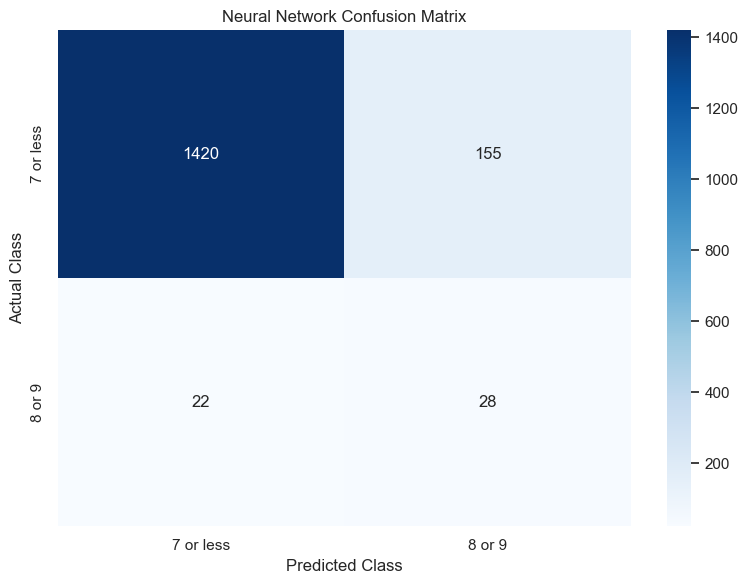

In [30]:
cm = confusion_matrix(y_test, test_predictions, labels=[0, 1])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["7 or less", "8 or 9"], yticklabels=["7 or less", "8 or 9"])
plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()